In [1]:
%load_ext autoreload
%autoreload 2

%pip install -r requirements.txt
%pip install -e .
%pip install matplotlib

import selfmade.nb101 as nb101

records = r'.\datas\nasbench_full.tfrecord'
space = nb101.NASBench101Space()
evaluator = nb101.NASBench101Evaluator(records, space)

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.


Obtaining file:///F:/vinh/vscs/fi
  Attempting uninstall: nasbench
    Found existing installation: nasbench 1.0
    Uninstalling nasbench-1.0:
      Successfully uninstalled nasbench-1.0
  Running setup.py develop for nasbench
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.



Loading dataset from file... This may take a few minutes...
Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Loaded dataset in 118 seconds


In [2]:
from sklearn.ensemble import RandomForestRegressor
import secrets
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
pop_size = 100
total_gen = 20
# Set seed để tạo tính công bằng cho 2 lượt chạy khác nhau
nb101.set_seed(42)

In [4]:
# Full vanilla (100 evals -> 10 pop, 10 iters)
def vanilla_run(size, loops):
    full_van = nb101.Population(size, space, evaluator)
    full_van.initialize()
    full_van.evolve_loop(total_gen=loops)
    return full_van

In [ ]:
# Half vanilla, half guided (100 evals -> 10 pop, 5 val, 5 gui)
def guided_run(size, loops):
    split = int(loops/2)
    semi_van = nb101.Population(size, space, evaluator)
    semi_van.initialize()
    semi_van.evolve_loop(total_gen=split)

    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)
    fi = nb101.FeatureImportance(space)
    imp = fi.pipeline(semi_van.data, rf)
    imp

    gui = nb101.Guidance(space, imp, semi_van.config)
    gui.sortNsplit()
    gui.calculate_guidance()

    semi_van.evolve_loop(total_gen=split, guidance = gui)
    return semi_van


In [6]:
fv = guided_run(pop_size, total_gen)
sv = vanilla_run(pop_size, total_gen)

Best performance: 0.9458132982254028
recording generation 0
finished recording
Generation 1
Best performance: 0.9458132982254028
recording generation 1
finished recording
Generation 2
Best performance: 0.9471153616905212
recording generation 2
finished recording
Generation 3
Best performance: 0.9474158883094788
recording generation 3
finished recording
Generation 4
Best performance: 0.9474158883094788
recording generation 4
finished recording
Generation 5
Best performance: 0.9474158883094788
recording generation 5
finished recording
Generation 6
Best performance: 0.9474158883094788
recording generation 6
finished recording
Generation 7
Best performance: 0.9485176205635071
recording generation 7
finished recording
Generation 8
Best performance: 0.9490184187889099
recording generation 8
finished recording
Generation 9
Best performance: 0.9490184187889099
recording generation 9
finished recording
Generation 10
Best performance: 0.9490184187889099
recording generation 10
finished recording

plot on full vanilla

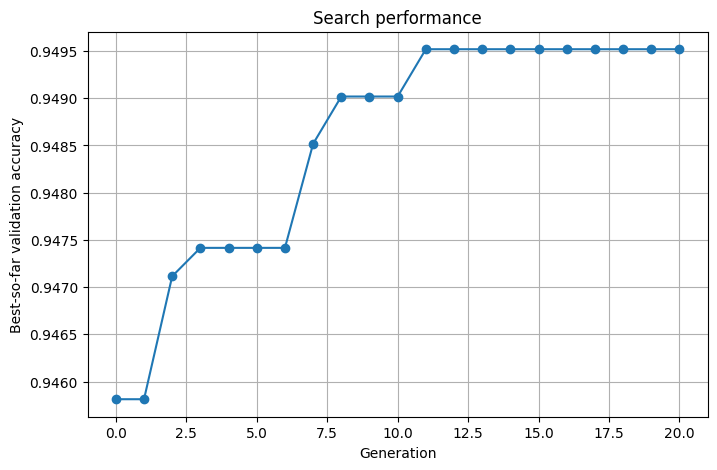

In [7]:
hist = pd.DataFrame(fv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

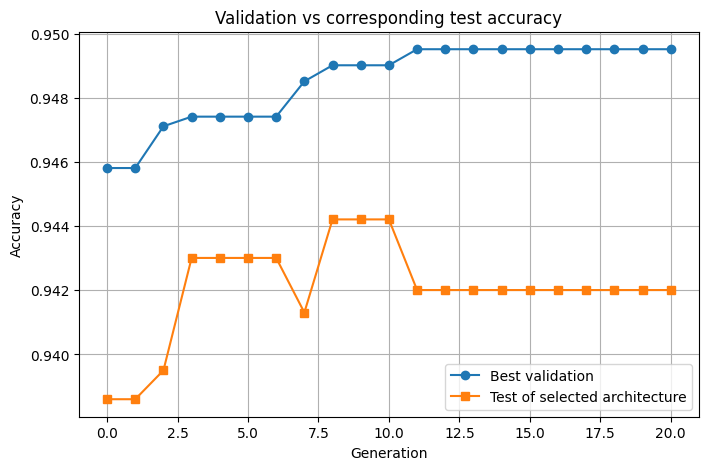

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

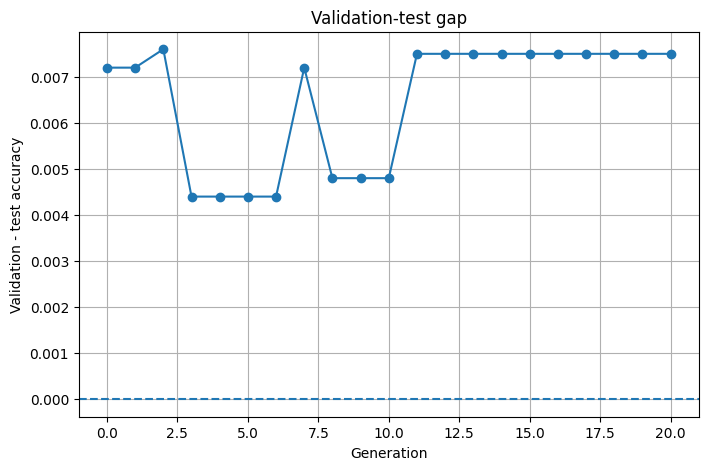

In [9]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

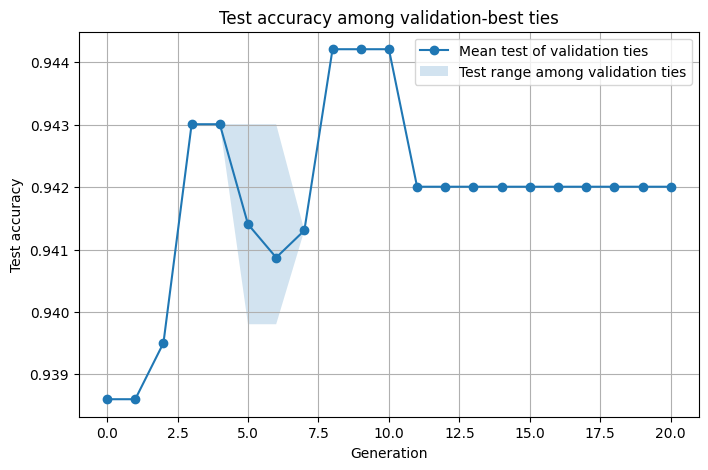

In [10]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df = pd.DataFrame(fv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

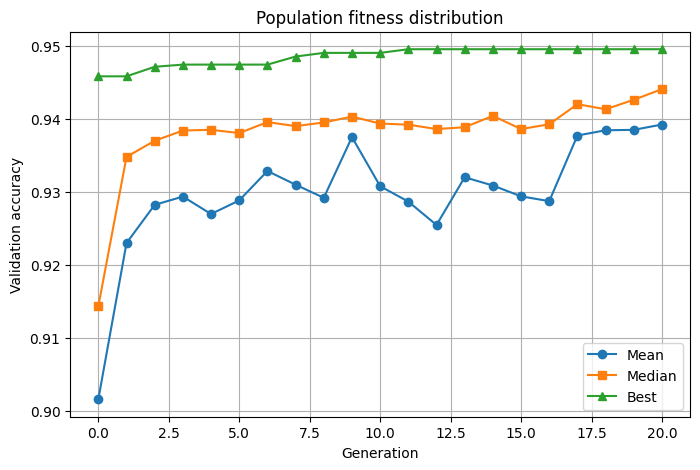

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def genome_signature(rep):
    return (
        rep["code"],
        tuple(rep["operations"])
    )

In [14]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

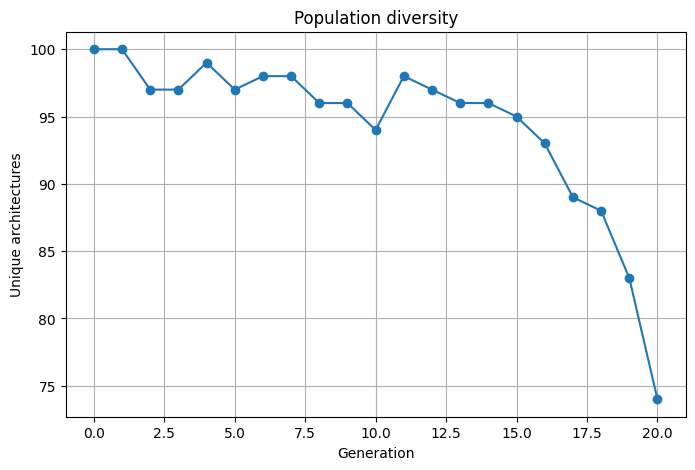

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

plot on vanilla + guided

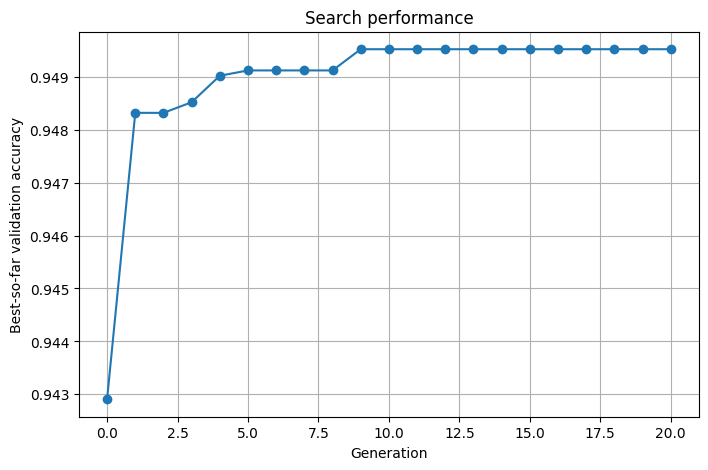

In [16]:
hist = pd.DataFrame(sv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

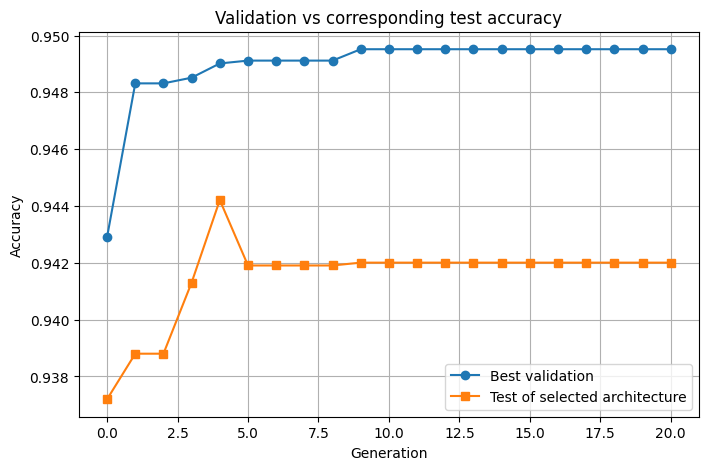

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)

plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

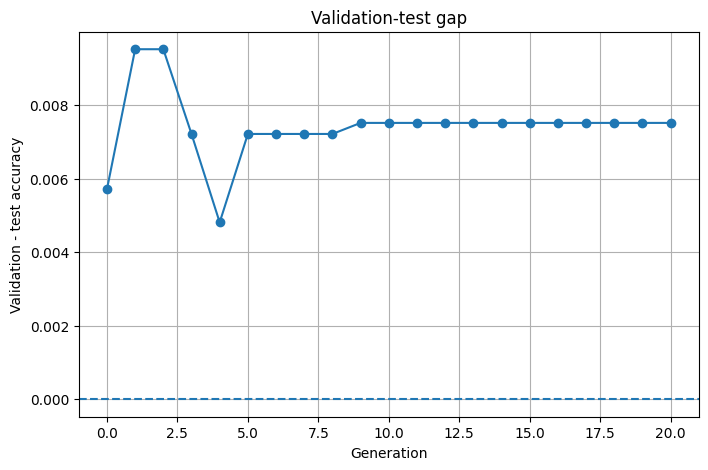

In [18]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

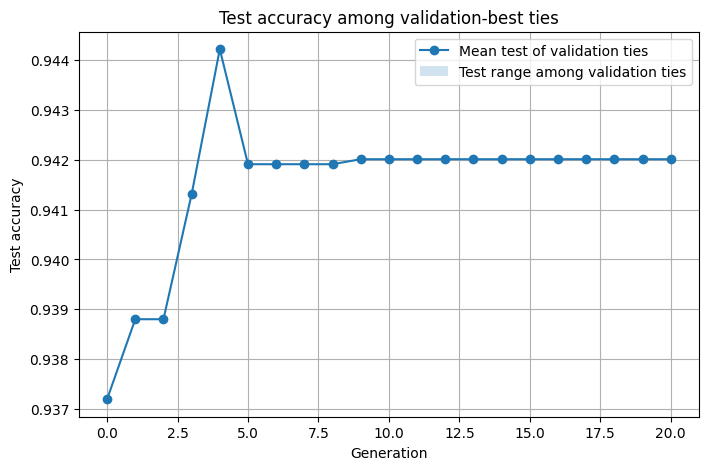

In [19]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
df = pd.DataFrame(sv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

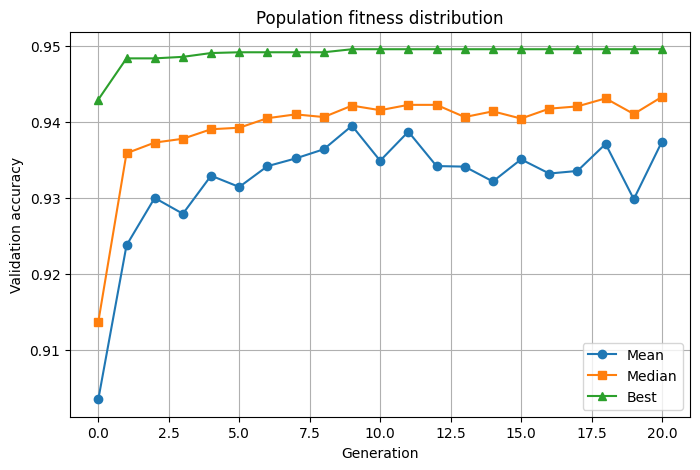

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

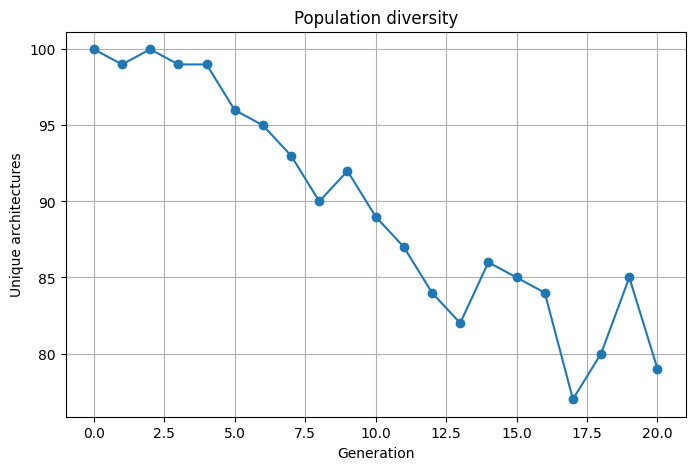

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

# 10 seed loop

In [45]:
def loopy_loop(n_runs, size, loops):
    fv_seed = []
    sv_seed = []
    seeds = []

    for run in range(n_runs):
        s = secrets.randbits(32)
        seeds.append(s)

        print(f"Running {run + 1}/{n_runs} | seed = {s}")

        nb101.set_seed(s)

        fv = vanilla_run(size, loops)
        fv_seed.append(fv)

        sv = guided_run(size, loops)
        sv_seed.append(sv)

    return fv_seed, sv_seed, seeds

In [57]:
fv, sv, seeds = loopy_loop(20, pop_size, 30)
# fv, sv, seeds = loopy_loop(20, pop_size * 2, 50)

Running 1/20 | seed = 2446489983
Best performance: 0.9436097741127014
recording generation 0
finished recording
Generation 1
Best performance: 0.9443109035491943
recording generation 1
finished recording
Generation 2
Best performance: 0.9466145634651184
recording generation 2
finished recording
Generation 3
Best performance: 0.9472155570983887
recording generation 3
finished recording
Generation 4
Best performance: 0.9481169581413269
recording generation 4
finished recording
Generation 5
Best performance: 0.9481169581413269
recording generation 5
finished recording
Generation 6
Best performance: 0.9481169581413269
recording generation 6
finished recording
Generation 7
Best performance: 0.9481169581413269
recording generation 7
finished recording
Generation 8
Best performance: 0.9490184187889099
recording generation 8
finished recording
Generation 9
Best performance: 0.9490184187889099
recording generation 9
finished recording
Generation 10
Best performance: 0.9490184187889099
recording

In [58]:
def make_history_df(runs, seeds, method):
    rows = []

    for pop, seed in zip(runs, seeds):
        for h in pop.best_history:
            rows.append({
                "seed": seed,
                "method": method,
                "generation": h["generation"],
                "best_val": h["best_val"],
                "best_so_far": h["best_so_far"],
                "best_test": h["best_test"],
                "tied_test_min": h["tied_test_min"],
                "tied_test_max": h["tied_test_max"],
                "tied_test_mean": h["tied_test_mean"],
                "num_tied": h["num_tied"],
            })

    return pd.DataFrame(rows)

In [59]:
vanilla_df = make_history_df(fv,seeds,"Vanilla")
guided_df = make_history_df(sv,seeds,"Guided")

history_df = pd.concat([vanilla_df, guided_df],ignore_index=True)

In [60]:
import numpy as np

def summarize(df):
    summary = (
        df.groupby(["method", "generation"])["best_so_far"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["sem"] = (
        summary["std"] /
        np.sqrt(summary["count"])
    )

    summary["ci95"] = 1.96 * summary["sem"]

    return summary

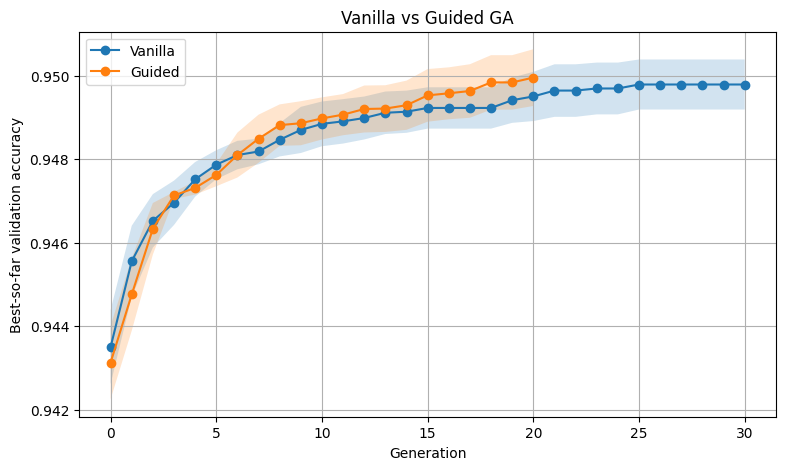

In [61]:
summary = summarize(history_df)

plt.figure(figsize=(9, 5))

for method in ["Vanilla", "Guided"]:
    d = summary[summary["method"] == method]

    plt.plot(
        d["generation"],
        d["mean"],
        marker="o",
        label=method
    )

    plt.fill_between(
        d["generation"],
        d["mean"] - d["ci95"],
        d["mean"] + d["ci95"],
        alpha=0.2
    )

plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Vanilla vs Guided GA")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
def final_results(df):
    final = (
        df.sort_values("generation")
        .groupby(["seed", "method"])
        .tail(1)
    )

    return final

In [63]:
final = final_results(history_df)

pivot = final.pivot(
    index="seed",
    columns="method",
    values="best_so_far"
)

pivot["improvement"] = (
    pivot["Guided"] - pivot["Vanilla"]
)

print(pivot)

method        Guided   Vanilla  improvement
seed                                       
129202930   0.951823  0.949119     0.002704
447484508   0.949519  0.949619    -0.000100
564212921   0.951823  0.949018     0.002805
1043892216  0.949519  0.949619    -0.000100
1139375086  0.949519  0.949519     0.000000
1197202139  0.951823  0.951823     0.000000
1261416237  0.951823  0.948618     0.003205
1957581226  0.948117  0.949519    -0.001402
2090155283  0.951823  0.951823     0.000000
2222191439  0.948117  0.948918    -0.000801
2228225035  0.948518  0.950321    -0.001803
2301019086  0.948918  0.948518     0.000401
2446280698  0.949519  0.948518     0.001002
2446489983  0.951122  0.949018     0.002103
2534543756  0.947216  0.951823    -0.004607
3147554629  0.948317  0.949018    -0.000701
3503416929  0.951122  0.951823    -0.000701
3841053553  0.949519  0.947216     0.002304
3884907201  0.949018  0.951823    -0.002805
4187870390  0.951823  0.950020     0.001803


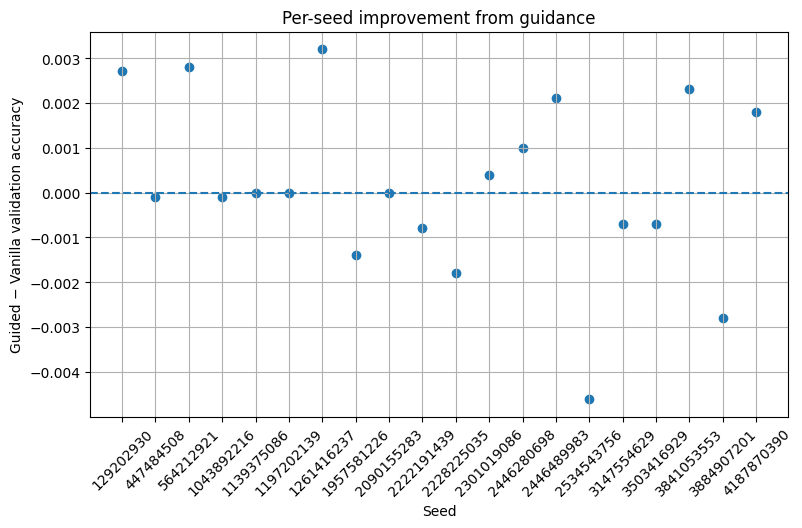

In [64]:
plt.figure(figsize=(9, 5))

x = np.arange(len(pivot))

plt.axhline(
    0,
    linestyle="--"
)

plt.scatter(
    x,
    pivot["improvement"]
)

plt.xticks(
    x,
    [str(s) for s in pivot.index],
    rotation=45
)

plt.xlabel("Seed")
plt.ylabel("Guided − Vanilla validation accuracy")
plt.title("Per-seed improvement from guidance")
plt.grid(True)
plt.show()

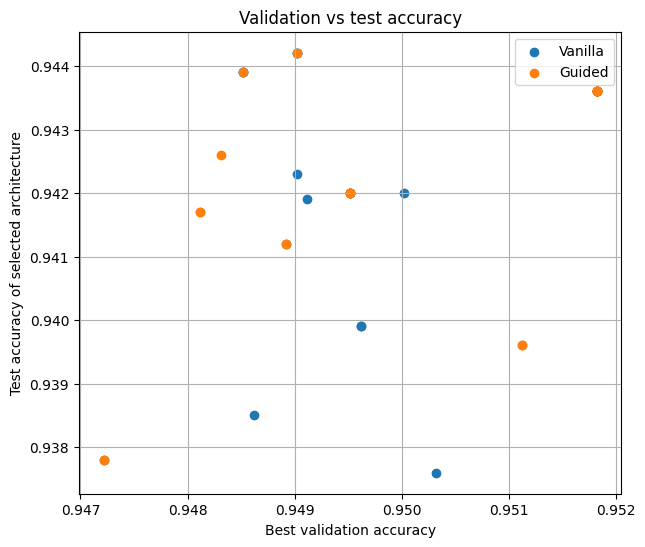

In [65]:
final_val = final.copy()

plt.figure(figsize=(7, 6))

for method in ["Vanilla", "Guided"]:
    d = final_val[final_val["method"] == method]

    plt.scatter(
        d["best_so_far"],
        d["best_test"],
        label=method
    )

plt.xlabel("Best validation accuracy")
plt.ylabel("Test accuracy of selected architecture")
plt.title("Validation vs test accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
final_val["val_test_gap"] = (
    final_val["best_so_far"]
    - final_val["best_test"]
)

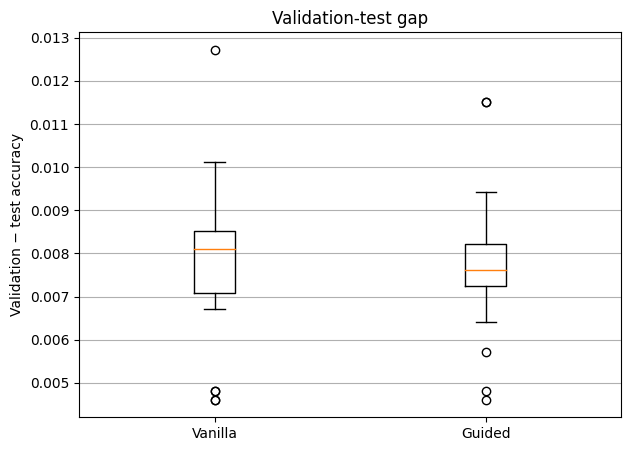

In [67]:
plt.figure(figsize=(7, 5))

groups = [
    final_val[
        final_val["method"] == "Vanilla"
    ]["val_test_gap"],

    final_val[
        final_val["method"] == "Guided"
    ]["val_test_gap"]
]

plt.boxplot(
    groups,
    labels=["Vanilla", "Guided"]
)

plt.ylabel("Validation − test accuracy")
plt.title("Validation-test gap")
plt.grid(True, axis="y")
plt.show()